Project---Online Retail Data Analysis

*Objective

Analyze customer transactions from the Online Retail dataset to uncover purchasing patterns, perform data cleaning, feature engineering, and exploratory data analysis (EDA), and generate insights for business decision-making.

Import Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

1. Load Dataset

In [33]:
df = pd.read_excel("online_retail_II.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [34]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


(525461, 8)

// Data Cleaning

Handle Missing Values

In [35]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [36]:
df = df.dropna(subset=['Customer ID'])
df = df.dropna(subset=['Description'])

In [37]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Remove Duplicates

In [38]:
df.duplicated().sum()

np.int64(6771)

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
df.duplicated().sum()

np.int64(0)

Outliers

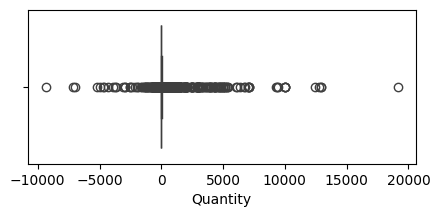

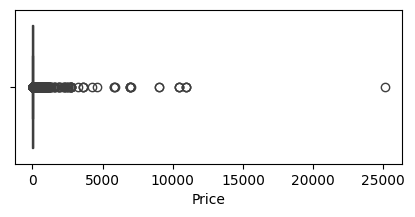

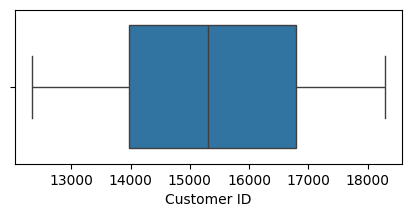

In [41]:
for i in df.select_dtypes(['int','float']).columns:
    plt.figure(figsize=(5,2))
    sns.boxplot(data=df,x=i);

Remove Outliers (IQR Method)

In [42]:
# A.IQR Method (Interquartile Range)
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1
# Define bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
lower,upper

(np.float64(-13.0), np.float64(27.0))

/// Feature Engineering

Total Price

In [43]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df[['Quantity','Price','TotalPrice']].head()

,Quantity,Price,TotalPrice
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


Time Features

In [44]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

df[['InvoiceDate','Year','Month','Day','Hour']].head()

,InvoiceDate,Year,Month,Day,Hour
0,2009-12-01 07:45:00,2009,12,1,7
1,2009-12-01 07:45:00,2009,12,1,7
2,2009-12-01 07:45:00,2009,12,1,7
3,2009-12-01 07:45:00,2009,12,1,7
4,2009-12-01 07:45:00,2009,12,1,7


Customer-Level Features

In [45]:
customer_df = df.groupby('Customer ID').agg({
    'Invoice': 'nunique',
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).reset_index()

customer_df.columns = ['CustomerID','Total_Transactions','Total_Items','Total_Spending']

customer_df.head()

,CustomerID,Total_Transactions,Total_Items,Total_Spending
0,12346.0,15,53,-51.74
1,12347.0,2,828,1323.32
2,12348.0,1,373,222.16
3,12349.0,4,988,2646.99
4,12351.0,1,261,300.93


Average Order Value

In [46]:
customer_df['Avg_Order_Value'] = customer_df['Total_Spending'] / customer_df['Total_Transactions']

customer_df[['CustomerID','Avg_Order_Value']].head()

,CustomerID,Avg_Order_Value
0,12346.0,-3.449333
1,12347.0,661.660000
2,12348.0,222.160000
3,12349.0,661.747500
4,12351.0,300.930000


///// Exploratory Data Analysis (EDA)

Top Products Analysis

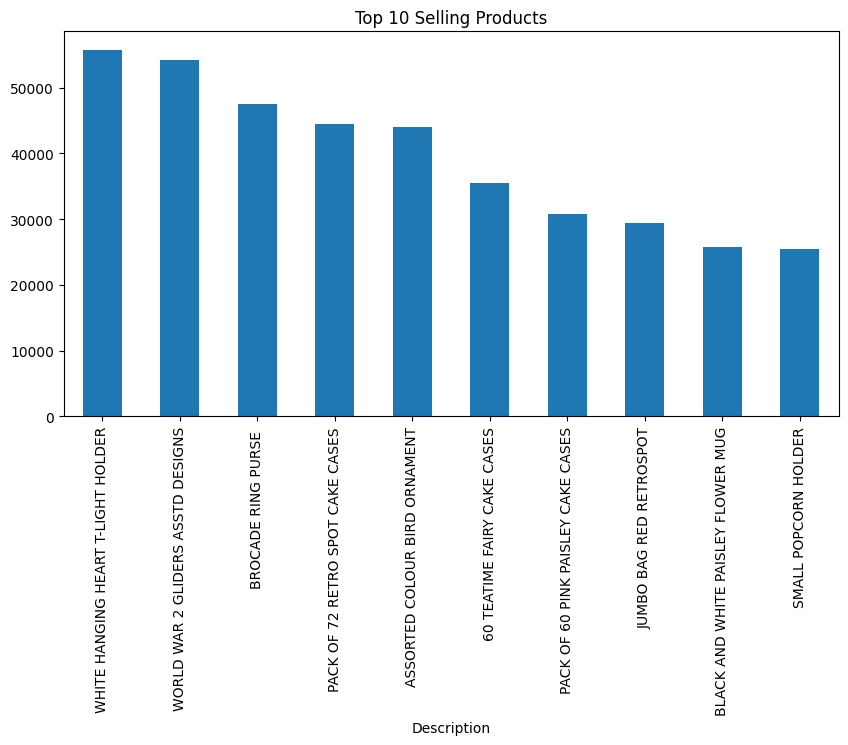

In [47]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Selling Products")
plt.show()

Sales by Country

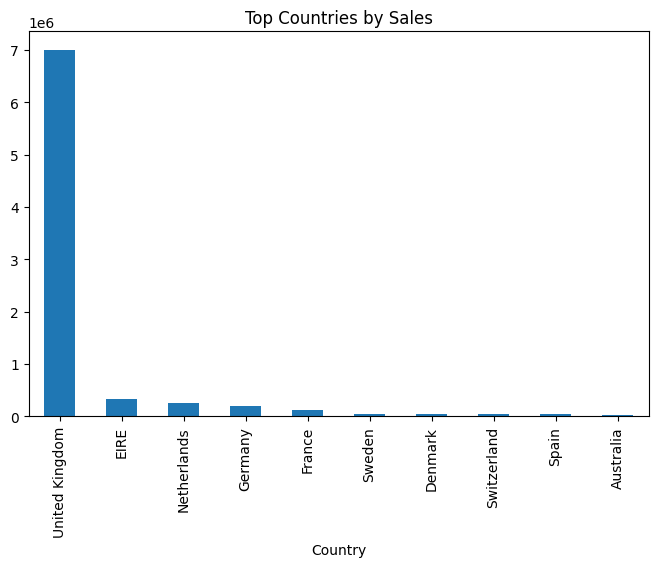

In [48]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar', figsize=(8,5))
plt.title("Top Countries by Sales")
plt.show()

Monthly Sales Trend

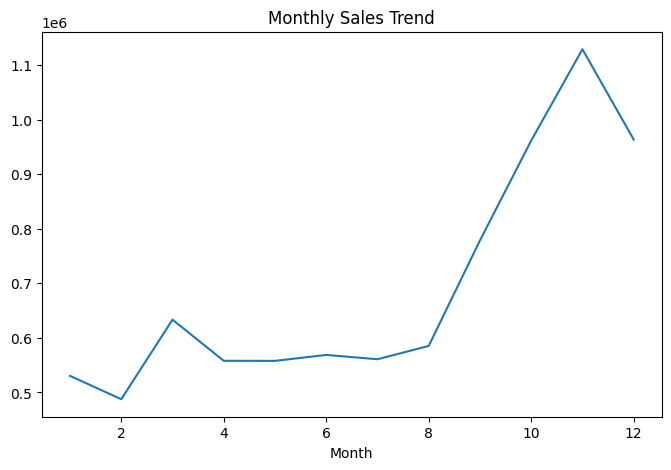

In [49]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.show()

Sales by Hour (Time Analysis)

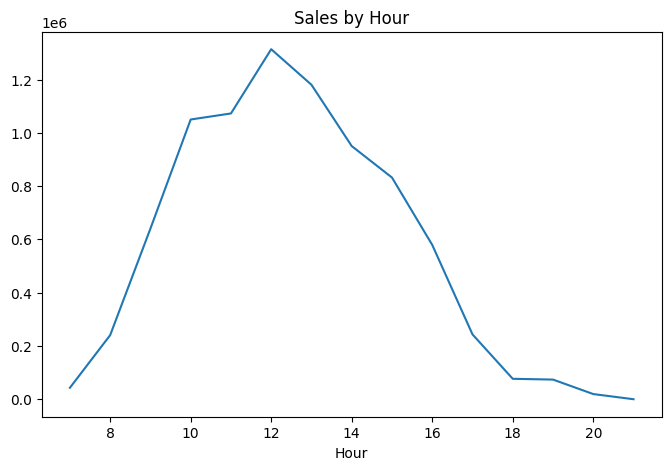

In [50]:
hourly_sales = df.groupby('Hour')['TotalPrice'].sum()

hourly_sales.plot(figsize=(8,5))
plt.title("Sales by Hour")
plt.show()

Top Customers

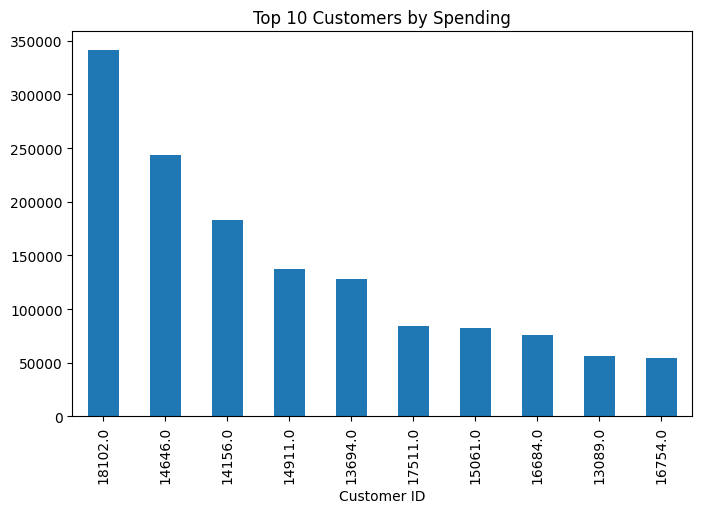

In [51]:
top_customers = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar', figsize=(8,5))
plt.title("Top 10 Customers by Spending")
plt.show()

Correlation Analysis

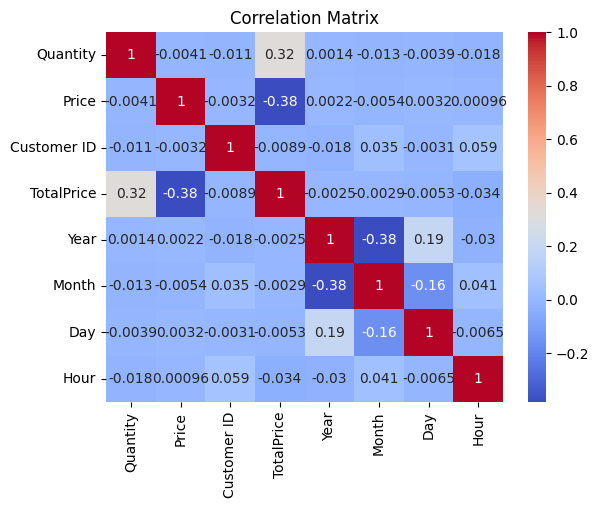

In [52]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [53]:

# RFM ANALYSIS
snapshot_date = (

    df['InvoiceDate'].max()

    + pd.Timedelta(days=1)
)
rfm = df.groupby('Customer ID').agg({

    'InvoiceDate':
    lambda x:
    (snapshot_date - x.max()).days,

    'Invoice': 'nunique',

    'TotalPrice': 'sum'
})
rfm.columns = [

    'Recency',

    'Frequency',

    'Monetary'
]
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346.0           67         15    -51.74
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          4   2646.99
12351.0           11          1    300.93


            Recency   Frequency       Monetary
Cluster                                       
0         42.936792    4.967610    1472.681719
1        244.847015    1.902052     403.763931
2          4.888889  137.000000  141907.743333
3         12.508197   37.032787   15751.828631


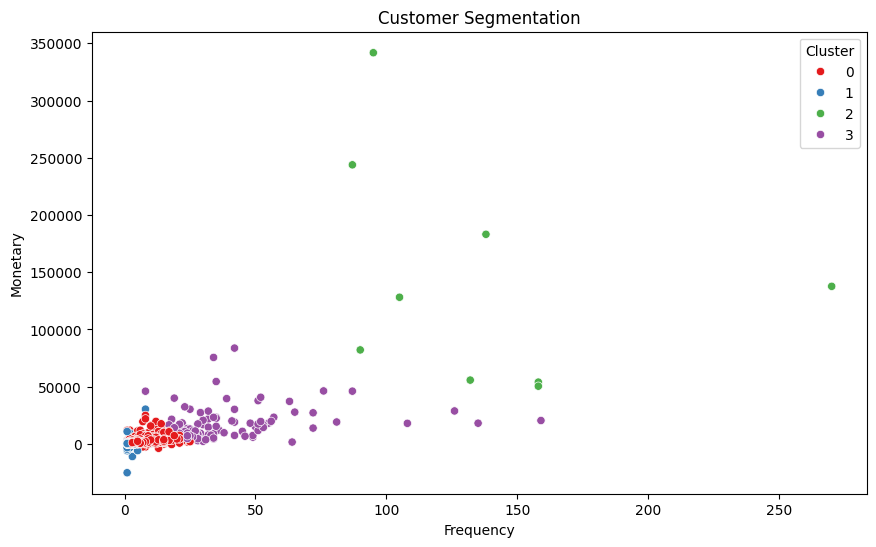

In [54]:
# CUSTOMER SEGMENTATION USING K-MEANS

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# Select RFM Features
rfm = rfm[['Recency', 'Frequency', 'Monetary']]

# Scaling
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Cluster Summary
print(rfm.groupby('Cluster').mean())

# Visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Set1'
)

plt.title("Customer Segmentation")

plt.show()

c:\Users\vinay\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\vinay\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\vinay\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\vinay\AppData\Local\Programs\Python\Python312\Lib

12    1.006972e+06
13    9.637220e+05
14    1.006778e+06
Name: predicted_mean, dtype: float64


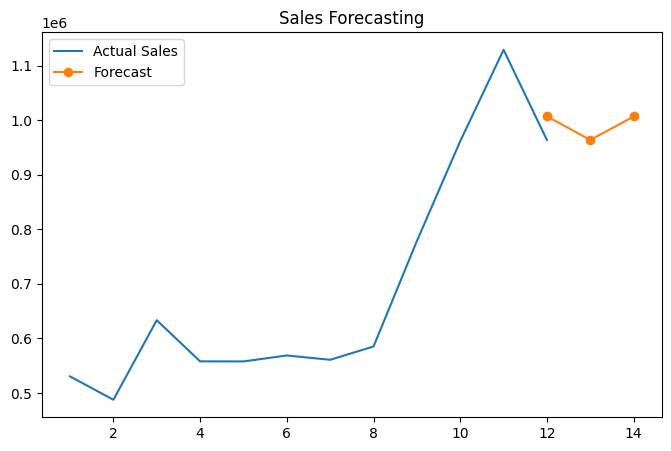

In [56]:

# SALES FORECASTING USING ARIMA

from statsmodels.tsa.arima.model import ARIMA

# Monthly Sales
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

# Build Model
model = ARIMA(monthly_sales, order=(1,1,1))

model_fit = model.fit()

# Forecast Next 3 Months
forecast = model_fit.forecast(steps=3)

print(forecast)
plt.figure(figsize=(8,5))

plt.plot(monthly_sales, label='Actual Sales')

plt.plot(
    range(len(monthly_sales),
    len(monthly_sales)+3),
    forecast,
    label='Forecast',
    marker='o'
)
plt.legend()
plt.title("Sales Forecasting")
plt.show()

In [ ]:
# PRODUCT RECOMMENDATION SYSTEM

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder

# Create Basket Matrix
# Create Basket Matrix using TransactionEncoder for memory efficiency

# Group by Invoice and collect unique Descriptions (assuming Quantity > 0 for purchases)
df = pd.read_excel("online_retail_II.xlsx")
transactions = df[df['Quantity'] > 0].groupby('Invoice')['Description'].apply(list).tolist()

# Encode transactions
te = TransactionEncoder()
basket = te.fit_transform(transactions)
basket = pd.DataFrame(basket, columns=te.columns_)
# Convert values into 0 and 1
basket = basket.map(lambda x: 1 if x > 0 else 0)
# Apply Apriori
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)
# Generate Rules
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1
)
# Display Recommendations
print(rules[['antecedents','consequents','support','confidence','lift']])

NameError: name 'df' is not defined

In [ ]:
# Save as app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Title
st.title("Online Retail Analytics Dashboard")

# Upload File
uploaded_file = st.file_uploader(
    "Upload Retail Dataset",
    type=['csv','xlsx']
)

if uploaded_file is not None:

    # Read File
    df = pd.read_excel(uploaded_file)

    st.write(df.head())

    # Total Revenue
    df['TotalPrice'] = df['Quantity'] * df['Price']

    revenue = df['TotalPrice'].sum()

    st.metric("Total Revenue", revenue)

    # Country Sales
    country_sales = (
        df.groupby('Country')['TotalPrice']
        .sum()
        .sort_values(ascending=False)
    )

    # Plot
    fig, ax = plt.subplots(figsize=(10,5))

    country_sales.head(10).plot(
        kind='bar',
        ax=ax
    )

    plt.title("Top Countries by Revenue")

    st.pyplot(fig)

2026-05-09 01:21:27.677 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 01:21:27.758 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 01:21:27.768 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 01:21:27.829 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 01:21:27.892 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 01:21:27.896 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 01:21:27.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-09 01:21:27.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar